# Set 01 — AI-Driven High Energy Physics

Completed assignment solutions.

## Exercise 01: Neutrinos from a banana cargo ship

### Answer

#### A. Estimate the neutrino flux

The dominant source is the beta decay of the radioactive isotope $^{40}\mathrm{K}$ naturally present in bananas:

$$
^{40}\mathrm{K}\rightarrow\,^{40}\mathrm{Ca}+e^-+\bar\nu_e.
$$

For an order-of-magnitude estimate, assume:

- one cargo ship carries $10^5$ tonnes of bananas,
- bananas contain approximately $450$ mg of potassium per $100$ g,
- the natural abundance of $^{40}\mathrm{K}$ is about $1.17\times10^{-4}$,
- the half-life of $^{40}\mathrm{K}$ is approximately $1.25\times10^9$ years,
- about $89\%$ of $^{40}\mathrm{K}$ decays produce an electron antineutrino,
- the ship remains in port for three days.

The calculation below estimates the total antineutrino emission rate and the isotropic flux at several distances. This is an approximate exercise: the result depends directly on the assumed cargo mass and detector distance.

#### B. Possible detection channels

Because these neutrinos have MeV-scale energies, possible interactions include:

1. **Neutrino–electron elastic scattering**
   $$
   \nu + e^- \rightarrow \nu + e^-.
   $$
   This is allowed for low-energy neutrinos, but the cross section is extremely small.

2. **Charged-current interactions on suitable nuclei**
   $$
   \nu_e + (A,Z)\rightarrow e^-+(A,Z+1),
   $$
   provided the neutrino energy exceeds the nuclear threshold.

3. **Coherent elastic neutrino–nucleus scattering (CE$\nu$NS)**
   $$
   \nu + A \rightarrow \nu + A.
   $$
   This has a comparatively larger coherent cross section at low energies, but requires a detector with a very low nuclear-recoil threshold.

#### C. Why inverse beta decay is not a solution

Inverse beta decay is

$$
\bar\nu_e+p\rightarrow e^++n.
$$

Its threshold is approximately $1.806$ MeV. The electron-antineutrino spectrum from $^{40}\mathrm{K}$ beta decay has an endpoint below this threshold, so these antineutrinos cannot trigger inverse beta decay. Therefore a standard proton-rich IBD detector is not suitable for detecting the banana-related $^{40}\mathrm{K}$ antineutrino flux.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Assumptions for an order-of-magnitude estimate
cargo_mass_tonnes = 1.0e5
cargo_mass_g = cargo_mass_tonnes * 1e6

# 450 mg potassium per 100 g of banana = 4.5 mg/g
potassium_mass_fraction = 4.5e-3
natural_abundance_K40 = 1.17e-4
branching_to_antineutrino = 0.89

molar_mass_K = 39.0983       # g/mol
avogadro = 6.02214076e23
half_life_years = 1.248e9
seconds_per_year = 365.25 * 24 * 3600

potassium_mass_g = cargo_mass_g * potassium_mass_fraction
K40_mass_g = potassium_mass_g * natural_abundance_K40
N_K40 = (K40_mass_g / molar_mass_K) * avogadro
decay_constant = np.log(2) / (half_life_years * seconds_per_year)

activity = decay_constant * N_K40
antineutrino_rate = activity * branching_to_antineutrino

print(f"Cargo mass: {cargo_mass_tonnes:.2e} tonnes")
print(f"Estimated 40K atoms: {N_K40:.3e}")
print(f"Total 40K activity: {activity:.3e} decays/s")
print(f"Estimated antineutrino emission rate: {antineutrino_rate:.3e} /s")

for distance_m in [1, 10, 100, 1000]:
    flux = antineutrino_rate / (4 * np.pi * distance_m**2)
    print(f"Flux at {distance_m:4d} m: {flux:.3e} /m^2/s")

three_days = 3 * 24 * 3600
total_antineutrinos = antineutrino_rate * three_days
print(f"Antineutrinos emitted during 3 days: {total_antineutrinos:.3e}")

Cargo mass: 1.00e+05 tonnes
Estimated 40K atoms: 8.109e+26
Total 40K activity: 1.427e+10 decays/s
Estimated antineutrino emission rate: 1.270e+10 /s
Flux at    1 m: 1.011e+09 /m^2/s
Flux at   10 m: 1.011e+07 /m^2/s
Flux at  100 m: 1.011e+05 /m^2/s
Flux at 1000 m: 1.011e+03 /m^2/s
Antineutrinos emitted during 3 days: 3.292e+15


---

# Exercise 02: Bayesian Parameter Estimation via Metropolis–Hastings MCMC

### Answer

I use the provided luminosity-distance dataset and implement the Metropolis–Hastings algorithm from scratch. The procedure is:

1. Define the flat $\Lambda$CDM luminosity-distance model.
2. Use the Gaussian log-likelihood specified in the assignment.
3. Apply uniform priors:
   - $50 < H_0 < 90$ km/s/Mpc,
   - $0.1 < \Omega_m < 0.6$.
4. Propose Gaussian jumps in both parameters.
5. Accept or reject proposals using the Metropolis–Hastings acceptance probability.
6. Discard an initial burn-in period and inspect the posterior distributions.

The proposal widths can be changed below. If they are too small, the chain moves slowly and samples are highly correlated. If they are too large, the acceptance rate becomes low because proposals frequently jump to regions of poor posterior probability. A useful proposal therefore balances exploration and acceptance.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid
from pathlib import Path

data_path = Path("data/mcmc_cosmo_data.txt")
z, D_obs, sigma_D = np.loadtxt(data_path, unpack=True)

print("Number of data points:", len(z))
print("z range:", z.min(), "to", z.max())

Number of data points: 20
z range: 0.01 to 1.0


In [3]:
C = 299792.458  # km/s

def luminosity_distance(z, H0, Omega_m, n_grid=4000):
    z = np.asarray(z)
    z_max = float(np.max(z))
    grid = np.linspace(0.0, z_max, n_grid)

    E = np.sqrt(Omega_m * (1 + grid)**3 + (1 - Omega_m))
    integral_grid = cumulative_trapezoid(1.0 / E, grid, initial=0.0)

    integral_at_z = np.interp(z, grid, integral_grid)
    return (C * (1 + z) / H0) * integral_at_z

def log_prior(H0, Omega_m):
    if 50.0 < H0 < 90.0 and 0.1 < Omega_m < 0.6:
        return 0.0
    return -np.inf

def log_likelihood(H0, Omega_m):
    D_model = luminosity_distance(z, H0, Omega_m)
    chi2 = np.sum(((D_obs - D_model) / sigma_D)**2)
    return -0.5 * chi2

def log_posterior(H0, Omega_m):
    lp = log_prior(H0, Omega_m)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(H0, Omega_m)

In [4]:
def metropolis_hastings(
    n_steps=50000,
    initial=(70.0, 0.3),
    proposal_widths=(0.8, 0.015),
    seed=42,
):
    rng = np.random.default_rng(seed)

    chain = np.zeros((n_steps, 2))
    current = np.array(initial, dtype=float)
    current_logp = log_posterior(*current)

    accepted = 0

    for i in range(n_steps):
        proposal = current + rng.normal(
            loc=0.0,
            scale=np.asarray(proposal_widths),
            size=2,
        )

        proposal_logp = log_posterior(*proposal)
        log_alpha = proposal_logp - current_logp

        if np.log(rng.random()) < min(0.0, log_alpha):
            current = proposal
            current_logp = proposal_logp
            accepted += 1

        chain[i] = current

    return chain, accepted / n_steps

chain, acceptance_rate = metropolis_hastings()

print(f"Acceptance rate: {acceptance_rate:.3f}")

Acceptance rate: 0.097


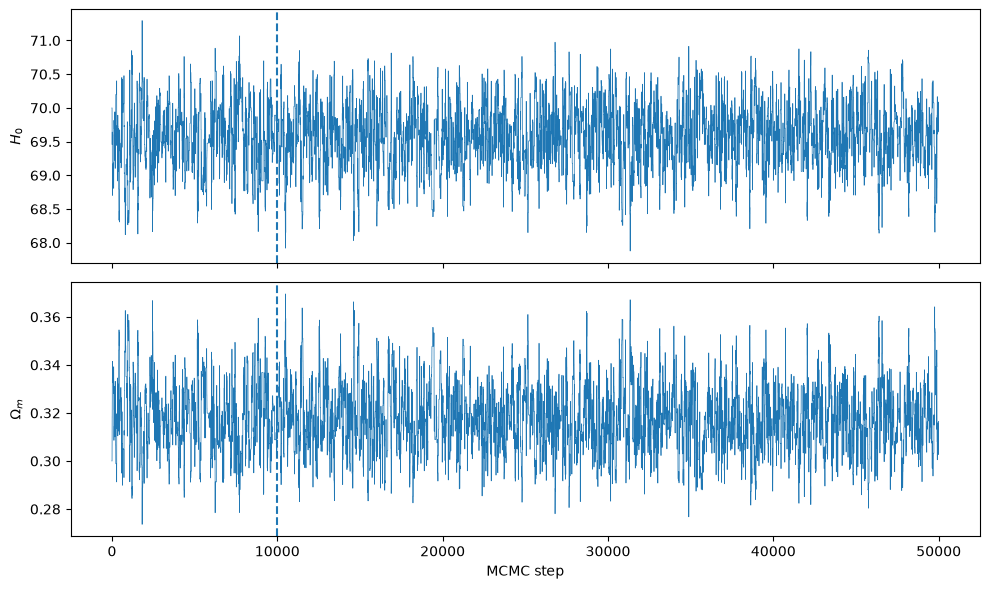

H0: 69.6088 (+0.4285, -0.4834)
Omega_m: 0.3167 (+0.0144, -0.0124)


In [5]:
burn_in = 10000
posterior = chain[burn_in:]

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(chain[:, 0], lw=0.5)
axes[0].axvline(burn_in, ls="--")
axes[0].set_ylabel(r"$H_0$")

axes[1].plot(chain[:, 1], lw=0.5)
axes[1].axvline(burn_in, ls="--")
axes[1].set_ylabel(r"$\Omega_m$")
axes[1].set_xlabel("MCMC step")

plt.tight_layout()
plt.show()

H0_samples = posterior[:, 0]
Om_samples = posterior[:, 1]

for name, samples in [(r"H0", H0_samples), (r"Omega_m", Om_samples)]:
    q16, q50, q84 = np.percentile(samples, [16, 50, 84])
    print(f"{name}: {q50:.4f} (+{q84-q50:.4f}, -{q50-q16:.4f})")

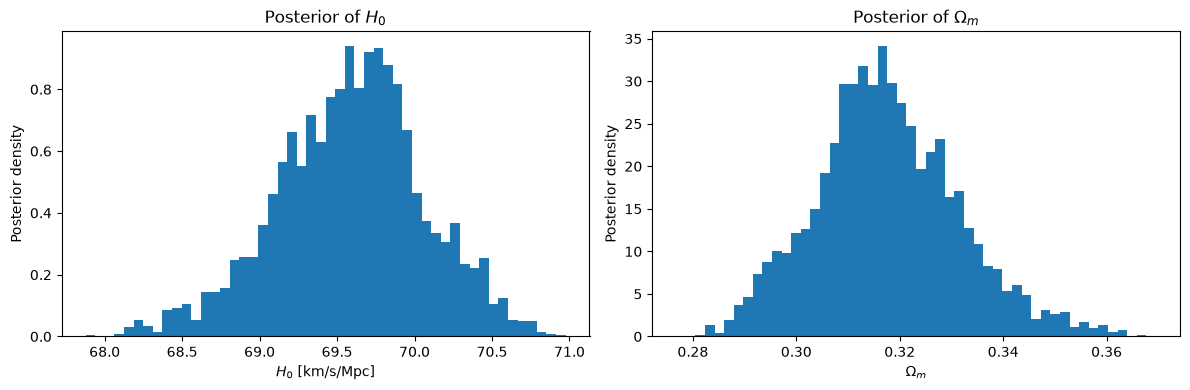

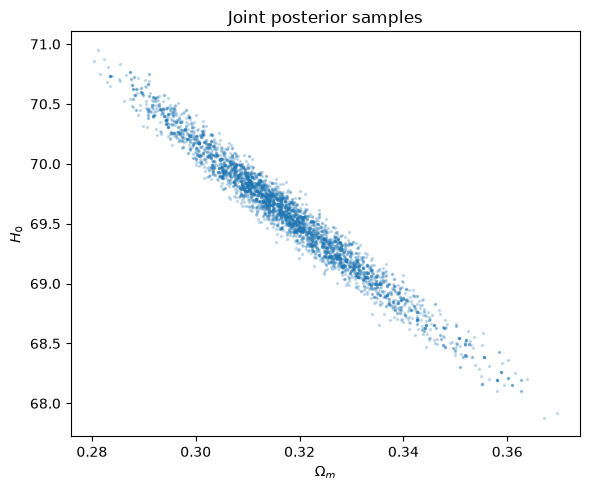

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(H0_samples, bins=50, density=True)
axes[0].set_xlabel(r"$H_0$ [km/s/Mpc]")
axes[0].set_ylabel("Posterior density")
axes[0].set_title(r"Posterior of $H_0$")

axes[1].hist(Om_samples, bins=50, density=True)
axes[1].set_xlabel(r"$\Omega_m$")
axes[1].set_ylabel("Posterior density")
axes[1].set_title(r"Posterior of $\Omega_m$")

plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
plt.scatter(Om_samples[::10], H0_samples[::10], s=2, alpha=0.2)
plt.xlabel(r"$\Omega_m$")
plt.ylabel(r"$H_0$")
plt.title("Joint posterior samples")
plt.tight_layout()
plt.show()

### Discussion of proposal widths

For this implementation, the proposal widths control the size of the random walk:

- **Smaller widths:** usually increase acceptance but lead to slow exploration and stronger autocorrelation.
- **Larger widths:** explore parameter space more aggressively but can reduce the acceptance rate.
- **Intermediate widths:** provide a practical compromise between exploration and acceptance.

For example, the code can be rerun with different values of `proposal_widths` and the acceptance rate and trace plots can be compared.